## **Step 1: Retrieval & Generation**

**Project:** *Towards Explainable and Reliable Large Language Models for Clinical Decision Support*

### Notebook objective

Generate reliable, evidence-grounded long answers for biomedical questions from **PubMedQA**, focusing on answer quality, faithfulness, citation consistency, and evidence traceability.

### Final selected configuration

| Component | Final choice |
| --------------------------- | ---------------------------------------- |
| Dataset | PubMedQA |
| Evaluation sample | Fixed **1000 PubMedQA questions** |
| Random seed | `42` |
| Retrieval method | Dense retrieval |
| Vector database | Qdrant |
| Embedding model | `sentence-transformers/all-MiniLM-L6-v2` |
| Retrieved candidates | `RETRIEVE_TOP_K = 12` |
| Kept evidence chunks | `KEEP_TOP_N = 3` with adaptive Keep-N |
| Adaptive Keep-N gap | `0.08` |
| Evidence threshold | `MIN_EVIDENCE_SCORE = 0.58` |
| Evidence threshold fallback | Enabled |
| Same-PMID consistency | Enabled |
| Same-PMID bonus | `0.10` |
| Query re-ranking | Enabled |
| Query re-ranking weight | `0.15` |
| Conditional diversity | Enabled |
| Diversity similarity threshold | `0.82` |
| Diversity penalty | `0.25` |
| Generation model | `BioMistral/BioMistral-7B-DARE-GGUF` |
| Quantization | `Q4_K_M` |
| Selected temperature | `0.2` |
| Top-p | `0.85` |
| Repetition penalty | `1.20` |
| Target answer length | **2–4 sentences** |
| Citation repair | Lexical + semantic matching |
| Citation repair lexical threshold | `0.25` |
| Citation repair semantic threshold | `0.45` |
| NLI model | `microsoft/deberta-large-mnli` |
| BERTScore-F1 model | `distilbert-base-uncased` |

### Main pipeline steps

1. Load the processed PubMedQA QA table and precomputed evidence chunks.
2. Select or reload the same fixed **1000-question** evaluation sample.
3. Load MiniLM embeddings and build the Qdrant dense index.
4. Retrieve the **top-12** evidence chunks.
5. Apply the **same-PMID bonus of 0.10** to improve contextual consistency.
6. Apply **query re-ranking** to reinforce direct semantic relevance to the biomedical question.
7. Apply the **0.58 evidence threshold**, conditional diversity filtering, and adaptive Keep-N to retain up to 3 high-quality evidence chunks.
8. Activate the evidence fallback when no chunk reaches the minimum evidence threshold.
9. Generate concise evidence-grounded answers using BioMistral at temperature `0.2`, top-p `0.85`, and repetition penalty `1.20`.
10. Select the most evidence-grounded generated sentences and maintain a target length of **2–4 sentences**.
11. Parse and verify inline evidence citations.
12. Repair missing citations using lexical overlap and semantic similarity.
13. Clean answers for automatic metric computation while preserving cited answers for traceability.
14. Evaluate sentence-level faithfulness using supported, partially supported, and unsupported categories.
15. Compute answer quality, retrieval, faithfulness, and citation metrics.
16. Save final outputs, plots, and report-ready results.

### Final reported results

| Metric | Final value |
| ----------------------------------------- | ------------------: |
| ROUGE-1 cleaned | **0.3260** |
| ROUGE-L cleaned | **0.2103** |
| BLEU-4 cleaned | **5.4583** |
| BLEU-1 cleaned | **0.2169** |
| BERTScore Precision | **78.68%** |
| BERTScore Recall | **83.15%** |
| BERTScore-F1 cleaned | **80.78%** |
| Answer Relevancy | **79.23%** |
| Context Precision | **90.80%** |
| Context Recall | **97.40%** |
| METEOR | **0.2557** |
| Faithfulness | **0.8300** |
| Supported sentence rate | **0.3538** |
| Partially supported sentence rate | **0.1316** |
| Unsupported sentence rate | **0.0307** |
| Citation consistency | **0.9954** |
| Citation missing before → after repair | **0.4330 → 0.0010** |
| Cited sentence rate before → after repair | **0.2640 → 0.9901** |
| Evidence mismatch rate | **0.0070** |
| Same-PMID evidence rate | **0.9740** |

## 1. Configurations


In [1]:
# -----------------------------------------------------------------------------
# Setup cell
# - Imports the libraries used throughout the final RAG pipeline.
# - Defines paths, constants, final configuration, model names, thresholds,
#   generation settings, and output folders.
# - Creates the output directories used to save CSV files and plots.
# -----------------------------------------------------------------------------
import ast
import json
import re
import string
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib
try:
    from IPython import get_ipython
    if get_ipython() is None:
        matplotlib.use("Agg")
except Exception:
    pass
import matplotlib.pyplot as plt
from IPython.display import display

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct

import nltk
from nltk.tokenize import sent_tokenize
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

from llama_cpp import Llama, LogitsProcessorList, LlamaGrammar

from dotenv import load_dotenv

import warnings
warnings.filterwarnings("ignore")

load_dotenv()
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 140)

# ---------- Paths ----------
PROCESSED_DIR = Path("data/processed")
OUTPUT_DIR = Path("data/outputs/final_rag_pipeline_v5")
PLOTS_DIR = OUTPUT_DIR / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

QA_CSV_PATH = PROCESSED_DIR / "pubmedqa_qa.csv"
CHUNKS_PARQUET_PATH = PROCESSED_DIR / "pubmedqa_chunks.parquet"
CHUNKS_CSV_PATH = PROCESSED_DIR / "pubmedqa_chunks.csv"

# ---------- Final configuration (V5: V2 recall + V3 quality + V4 diversity + improved prompt) ----------
FINAL_CONFIG = {
    "name": "minilm_k12_n3_e058_t02_v5optimized",
    "embedding_model": "sentence-transformers/all-MiniLM-L6-v2",
    "retrieval_method": "dense",
    "same_pmid": True,
    "retrieve_top_k": 12,
    "keep_top_n": 3,
    "min_evidence_score": 0.58,
    "temperature": 0.2,
}
EMBEDDING_MODEL_KEY = "minilm"

# ---------- Retrieval (dense only - no BM25, no cross-encoder, no Hybrid RRF) ----------
RETRIEVE_TOP_K = FINAL_CONFIG["retrieve_top_k"]
KEEP_TOP_N = FINAL_CONFIG["keep_top_n"]
MIN_EVIDENCE_SCORE = FINAL_CONFIG["min_evidence_score"]
EVIDENCE_THRESHOLD_FALLBACK = True   # never hand the LLM an empty context
SAME_PMID_BONUS = 0.10               # generation-time same-PMID consistency boost (V2 lesson)
DIVERSITY_PENALTY = 0.25              # gentler penalty from V4 (0.30) to preserve high-quality evidence
DIVERSITY_SIM_THRESHOLD = 0.82       # only apply diversity penalty when chunk sim exceeds this
QUERY_RERANK_WEIGHT = 0.15           # weight for query-chunk re-ranking in evidence selection
ADAPTIVE_KEEP_GAP = 0.08             # score gap threshold for adaptive Keep-N

# ---------- Generation ----------
LLM_GGUF_REPO_ID = "BioMistral/BioMistral-7B-DARE-GGUF"
LLM_GGUF_FILENAME = "ggml-model-Q4_K_M.gguf"
N_CTX = 4096
N_GPU_LAYERS = -1
N_THREADS = None

TARGET_MIN_SENTENCES = 2
TARGET_MAX_SENTENCES = 4
GENERATION_PARAMS = {
    "top_p": 0.85, "repeat_penalty": 1.20,
    "max_tokens": 260, "min_new_tokens": 55,
}
MAX_GEN_ATTEMPTS = 2

SELECTED_TEMPERATURE = FINAL_CONFIG["temperature"]
SUMMARY_TEMPERATURE = 0.2

# ---------- Citation repair ----------
MIN_REPAIR_OVERLAP = 0.25   # keyword-overlap fraction required to auto-repair a citation
# Semantic fallback (from v2-claude): if keyword overlap is too weak, repair when the MiniLM
# cosine similarity between the sentence and an evidence chunk reaches this threshold.
MIN_REPAIR_SEMANTIC_SIMILARITY = 0.45

# ---------- Faithfulness v2 (probabilistic NLI + lexical grounding hybrid) ----------
NLI_MODEL_NAME = "microsoft/deberta-large-mnli"
ENTAIL_WEIGHT = 0.60        # weight of the NLI entailment probability in the combined score
OVERLAP_WEIGHT = 0.40       # weight of the lexical overlap with evidence in the combined score
SUPPORTED_COMBINED_THRESHOLD = 0.50
CONTRADICT_PROB_THRESHOLD = 0.60

# ---------- Evaluation ----------
N_SAMPLE_QUESTIONS = 1000
RANDOM_SEED = 42
BERTSCORE_MODEL = "distilbert-base-uncased"

REQUIRED_CHUNK_COLUMNS = [
    "chunk_id", "doc_id", "pmid", "question", "chunk_text", "chunk_index",
    "source", "gold_long_answer", "gold_final_decision", "metadata",
]

print("Configuration loaded.")
print(f"Final configuration: {FINAL_CONFIG['name']}")
print(f"Selected fixed temperature: {SELECTED_TEMPERATURE}")
print(f"Sample size: {N_SAMPLE_QUESTIONS} (random_state={RANDOM_SEED})")



Configuration loaded.
Final configuration: minilm_k12_n3_e058_t02_v5optimized
Selected fixed temperature: 0.2
Sample size: 1000 (random_state=42)


## 2. Load PubMedQA data and precomputed evidence chunks


In [2]:
# -----------------------------------------------------------------------------
# Load the processed PubMedQA QA table and evidence chunks.
# The QA table contains questions and gold long answers.
# The chunk table contains the evidence passages that will be indexed for RAG.
# -----------------------------------------------------------------------------
if not QA_CSV_PATH.exists():
    raise FileNotFoundError(f"{QA_CSV_PATH} not found. Please run Notebook 1 first.")
qa_df = pd.read_csv(QA_CSV_PATH)
print(f"Loaded QA DataFrame: {len(qa_df)} rows")

if CHUNKS_PARQUET_PATH.exists():
    chunk_df = pd.read_parquet(CHUNKS_PARQUET_PATH)
elif CHUNKS_CSV_PATH.exists():
    chunk_df = pd.read_csv(CHUNKS_CSV_PATH)
else:
    raise FileNotFoundError(f"Could not find chunk file at {CHUNKS_PARQUET_PATH} or {CHUNKS_CSV_PATH}.")
print(f"Loaded Chunk DataFrame: {len(chunk_df)} rows")

if "metadata" in chunk_df.columns and isinstance(chunk_df["metadata"].iloc[0], str):
    parsed = []
    for v in chunk_df["metadata"]:
        try:
            parsed.append(ast.literal_eval(v))
        except Exception:
            parsed.append(json.loads(v))
    chunk_df["metadata"] = parsed

missing_cols = [c for c in REQUIRED_CHUNK_COLUMNS if c not in chunk_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in chunk_df: {missing_cols}")
print("All required chunk columns are present.")


Loaded QA DataFrame: 1000 rows
Loaded Chunk DataFrame: 1483 rows
All required chunk columns are present.


## 3. Fixed 1000-question evaluation sample


In [3]:
# -----------------------------------------------------------------------------
# Load or create the fixed 100-question evaluation sample.
# Reusing the same sample ensures that all metrics remain comparable and stable.
# -----------------------------------------------------------------------------
V2_SAMPLES_PATH = OUTPUT_DIR / "final_selected_1000_samples.csv"
LEGACY_SAMPLES_PATH = Path("data/outputs/final_rag_pipeline/selected_1000_pubmedqa_test_samples.csv")

if V2_SAMPLES_PATH.exists():
    sample_df = pd.read_csv(V2_SAMPLES_PATH)
    print(f"Reloaded existing v2 sample: {V2_SAMPLES_PATH} ({len(sample_df)} rows)")
elif LEGACY_SAMPLES_PATH.exists():
    sample_df = pd.read_csv(LEGACY_SAMPLES_PATH)
    sample_df.to_csv(V2_SAMPLES_PATH, index=False)
    print(f"Reloaded the same 100 samples from the previous final notebook ({len(sample_df)} rows).")
    print(f"Saved a copy to: {V2_SAMPLES_PATH}")
else:
    sample_df = qa_df.dropna(subset=["question"]).sample(
        n=min(N_SAMPLE_QUESTIONS, len(qa_df)), random_state=RANDOM_SEED
    ).reset_index(drop=True)
    sample_df.to_csv(V2_SAMPLES_PATH, index=False)
    print(f"No existing sample found; created a new reproducible sample. Saved: {V2_SAMPLES_PATH}")

sample_questions = sample_df["question"].tolist()
print(f"Using {len(sample_df)} fixed PubMedQA test questions.")


No existing sample found; created a new reproducible sample. Saved: data\outputs\final_rag_pipeline_v5\final_selected_1000_samples.csv
Using 1000 fixed PubMedQA test questions.


## 4. Embedding model and Qdrant index


In [4]:
# -----------------------------------------------------------------------------
# Load the selected MiniLM embedding model and create the Qdrant index.
# Cached embeddings are used if available; otherwise, embeddings are computed.
# Each evidence chunk is inserted into Qdrant with its metadata for traceability.
# -----------------------------------------------------------------------------
embedding_models = {}
clients = {}
collection_names = {}

model_name = FINAL_CONFIG["embedding_model"]
print(f"Loading embedding model [{EMBEDDING_MODEL_KEY}]: {model_name}")
model = SentenceTransformer(model_name)
dim = model.get_sentence_embedding_dimension()
embedding_models[EMBEDDING_MODEL_KEY] = model

embeddings_path = PROCESSED_DIR / f"pubmedqa_chunk_embeddings_{EMBEDDING_MODEL_KEY}.npy"
if embeddings_path.exists():
    print(f"Loading cached embeddings: {embeddings_path}")
    embeddings = np.load(embeddings_path)
else:
    print("Computing embeddings (first time for this model) ...")
    embeddings = model.encode(
        chunk_df["chunk_text"].tolist(), batch_size=32,
        normalize_embeddings=True, convert_to_numpy=True, show_progress_bar=True,
    )
    np.save(embeddings_path, embeddings)
    print(f"Saved: {embeddings_path}")

if embeddings.shape[0] != len(chunk_df):
    raise ValueError("Embedding rows do not match chunk_df rows.")

client = QdrantClient(":memory:")
collection_name = "pubmedqa_chunks_minilm"
client.recreate_collection(
    collection_name=collection_name,
    vectors_config=VectorParams(size=dim, distance=Distance.COSINE),
)
payload_cols = ["chunk_id", "doc_id", "pmid", "question", "chunk_text",
                 "gold_final_decision", "gold_long_answer"]
payloads = chunk_df[payload_cols].to_dict(orient="records")
for start in tqdm(range(0, len(embeddings), 256), desc="Qdrant upsert"):
    end = min(start + 256, len(embeddings))
    points = [PointStruct(id=i, vector=embeddings[i].tolist(), payload=payloads[i]) for i in range(start, end)]
    client.upsert(collection_name=collection_name, points=points)

clients[EMBEDDING_MODEL_KEY] = client
collection_names[EMBEDDING_MODEL_KEY] = collection_name
n_stored = client.get_collection(collection_name).points_count
print(f"Qdrant points stored: {n_stored}")

# Map each question to its own gold PMID (used only for the same-PMID *evaluation metric*,
# never for generation-time retrieval).
question_to_gold_pmid = (
    chunk_df.drop_duplicates(subset=["question"])
    .set_index("question")["pmid"]
    .to_dict()
)


Loading embedding model [minilm]: sentence-transformers/all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading cached embeddings: data\processed\pubmedqa_chunk_embeddings_minilm.npy


Qdrant upsert: 100%|██████████| 6/6 [00:00<00:00, 12.81it/s]

Qdrant points stored: 1483


## 5. Dense retrieval with same-PMID consistency (V5: query re-ranking + adaptive Keep-N)


In [5]:
# -----------------------------------------------------------------------------
# Retrieval function (V5).
# V5 improvements over V4:
#   - Query-chunk re-ranking: after initial retrieval + PMID bonus, re-score
#     candidates by query-chunk cosine similarity to ensure query relevance.
#   - Conditional diversity: only apply diversity penalty when chunks are
#     very similar (>DIVERSITY_SIM_THRESHOLD), preserving high-quality evidence.
#   - Adaptive Keep-N: if the score gap between rank-2 and rank-3 is too large,
#     keep only 2 chunks (combining V1's precision with V2/V3's recall).
# -----------------------------------------------------------------------------
def retrieve_evidence(model_key, question, threshold, top_k=RETRIEVE_TOP_K, keep_top_n=KEEP_TOP_N):
    model = embedding_models[model_key]
    client = clients[model_key]
    collection_name = collection_names[model_key]
    gold_pmid = question_to_gold_pmid.get(question)

    query_embedding = model.encode([question], normalize_embeddings=True, convert_to_numpy=True)[0]
    hits = client.query_points(collection_name=collection_name, query=query_embedding.tolist(), limit=top_k).points

    rows = []
    for h in hits:
        payload = h.payload or {}
        rows.append({
            "chunk_id": payload.get("chunk_id"), "pmid": payload.get("pmid"),
            "chunk_text": payload.get("chunk_text"), "cosine_score": float(h.score), "score": float(h.score),
        })
    cand = pd.DataFrame(rows)
    if len(cand) == 0:
        return cand, cand.copy()

    cand["is_gold"] = (cand["pmid"].astype(str) == str(gold_pmid)) if gold_pmid is not None else False

    cand = cand.sort_values("score", ascending=False).reset_index(drop=True)
    top_pmid = cand.iloc[0]["pmid"]
    cand["same_pmid_match"] = cand["pmid"].astype(str) == str(top_pmid)
    cand.loc[cand["same_pmid_match"], "score"] += SAME_PMID_BONUS
    cand = cand.sort_values("score", ascending=False).reset_index(drop=True)

    # V5: Query-chunk re-ranking
    # Re-score each candidate by computing fresh query-chunk cosine similarity
    # and blending it with the retrieval score.
    chunk_texts = cand["chunk_text"].tolist()
    chunk_embs = model.encode(chunk_texts, normalize_embeddings=True, convert_to_numpy=True)
    query_chunk_sims = chunk_embs @ query_embedding
    cand["query_relevance"] = query_chunk_sims
    cand["score"] = (1 - QUERY_RERANK_WEIGHT) * cand["score"] + QUERY_RERANK_WEIGHT * cand["query_relevance"]
    cand = cand.sort_values("score", ascending=False).reset_index(drop=True)
    cand.insert(0, "rank", range(1, len(cand) + 1))

    above = cand[cand["score"] >= threshold].reset_index(drop=True)
    below = cand[cand["score"] < threshold].reset_index(drop=True)

    threshold_fallback = False
    if len(above) == 0 and EVIDENCE_THRESHOLD_FALLBACK:
        above = cand.head(1).reset_index(drop=True)
        below = cand.iloc[1:].reset_index(drop=True)
        threshold_fallback = True

    # V5: Adaptive Keep-N - if score gap between rank 2 and 3 is too large, keep only 2
    adaptive_keep_n = keep_top_n
    if len(above) >= 3 and keep_top_n >= 3:
        score_gap = above.iloc[1]["score"] - above.iloc[2]["score"]
        if score_gap > ADAPTIVE_KEEP_GAP:
            adaptive_keep_n = 2

    kept = above.head(adaptive_keep_n).reset_index(drop=True)

    # V5: Conditional diversity - only apply when chunks are very similar
    if len(above) > 1 and adaptive_keep_n > 1:
        from sklearn.metrics.pairwise import cosine_similarity as _cs
        sel = []
        remaining = above.copy()
        for _ in range(min(adaptive_keep_n, len(remaining))):
            best_idx, best_score = None, -1.0
            for idx, row in remaining.iterrows():
                pen = 0.0
                if sel:
                    sel_texts = [s["chunk_text"] for s in sel]
                    sims = model.encode([row["chunk_text"]] + sel_texts, normalize_embeddings=True)
                    max_sim = float(max(_cs([sims[0]], sims[1:])[0]))
                    # V5: Only penalize if chunks are very similar (above threshold)
                    if max_sim > DIVERSITY_SIM_THRESHOLD:
                        pen = DIVERSITY_PENALTY * max_sim
                adj = row["score"] - pen
                if adj > best_score:
                    best_score, best_idx = adj, idx
            sel.append(remaining.loc[best_idx])
            remaining = remaining.drop(best_idx)
            if len(remaining) == 0:
                break
        kept = pd.DataFrame(sel).reset_index(drop=True)

    overflow = above.iloc[adaptive_keep_n:].reset_index(drop=True)
    if len(overflow) > 0:
        overflow = overflow.copy(); overflow["ignore_reason"] = "exceeded keep-top-N cutoff"
    if len(below) > 0:
        below = below.copy(); below["ignore_reason"] = "similarity score below threshold"
    ignored = pd.concat([overflow, below], ignore_index=True) if (len(overflow) or len(below)) else cand.iloc[0:0].copy().assign(ignore_reason=[])

    kept = kept.copy()
    kept["threshold_fallback"] = threshold_fallback
    kept["n_above_threshold"] = len(above)
    return kept, ignored


print("retrieve_evidence() ready (V5: query re-ranking + conditional diversity + adaptive Keep-N).")


retrieve_evidence() ready (V5: query re-ranking + conditional diversity + adaptive Keep-N).


## 6. PubMedQA-style generation prompt (V5: redesigned)

In [6]:
# -----------------------------------------------------------------------------
# Prompt construction.
# V5 redesigned prompt: more structured, shorter, stronger evidence anchoring.
# Key changes from V4:
#   - Explicit 2-4 sentence target (PubMedQA gold answers are 1-3 sentences)
#   - Explicit instruction to preserve exact biomedical terminology
#   - Structured format rules for the 7B model to follow
#   - Removed redundant instructions to reduce prompt length
# -----------------------------------------------------------------------------
CONCISE_INSTRUCTION = (
    "You are a biomedical researcher writing a PubMedQA-style evidence summary.\n\n"
    "TASK: Answer the question using ONLY the retrieved evidence blocks below.\n\n"
    "FORMAT:\n"
    "- Write 2 to 4 sentences total.\n"
    "- The first sentence must directly answer the question.\n"
    "- Each subsequent sentence adds one specific finding from the evidence.\n"
    "- Cite each sentence with (Evidence N) at the end.\n\n"
    "STYLE RULES:\n"
    "- Use the exact biomedical terms, statistics, and numbers from the evidence."
    " Do NOT paraphrase key terms.\n"
    "- Write as if continuing the conclusion of a scientific abstract.\n"
    "- Do NOT add: background, study importance, future research, disclaimers, or commentary.\n"
    "- Do NOT use openers like 'Based on the evidence' or 'According to the evidence'.\n"
    "- Only mention limitations if the evidence explicitly states them.\n"
    "- Do NOT invent statistics, numbers, or results not present in the evidence.\n"
    "- End immediately after the last evidence-supported sentence."
)


def build_concise_prompt(question, evidence_df):
    blocks = [
        f"[Evidence {i} | PMID: {row.pmid} | chunk_id: {row.chunk_id} | score: {row.score:.4f}]\n{row.chunk_text}"
        for i, row in enumerate(evidence_df.itertuples(index=False), start=1)
    ]
    evidence_text = "\n\n".join(blocks)
    return (CONCISE_INSTRUCTION + "\n\nEVIDENCE:\n" + evidence_text
            + "\n\nQUESTION: " + question + "\n\nANSWER:\n")


def split_sentences(text):
    return [s.strip() for s in sent_tokenize(str(text)) if len(s.strip().split()) >= 2]


## 7. Load BioMistral generation model


In [7]:
# -----------------------------------------------------------------------------
# Load BioMistral through llama-cpp.
# This cell keeps the same generation model and runtime settings used for the
# final reported results.
# -----------------------------------------------------------------------------
import llama_cpp
gpu_supported = getattr(llama_cpp, "GGML_USE_CUBLAS", False) or getattr(llama_cpp, "GGML_USE_METAL", False)
n_gpu_layers = N_GPU_LAYERS if gpu_supported else 0
print(f"GPU support detected: {gpu_supported} -> n_gpu_layers={n_gpu_layers}")

llm = Llama.from_pretrained(
    repo_id=LLM_GGUF_REPO_ID, filename=LLM_GGUF_FILENAME,
    n_ctx=N_CTX, n_gpu_layers=n_gpu_layers, n_threads=N_THREADS, verbose=False,
)
eos_token_id = llm.token_eos()


class MinNewTokensLogitsProcessor:
    def __init__(self, min_new_tokens, eos_token_id):
        self.min_new_tokens = min_new_tokens
        self.eos_token_id = eos_token_id
        self.prompt_tokens = None

    def __call__(self, input_ids, scores):
        if self.prompt_tokens is None:
            self.prompt_tokens = len(input_ids)
        if len(input_ids) - self.prompt_tokens < self.min_new_tokens:
            scores[self.eos_token_id] = float("-inf")
        return scores


print("BioMistral ready.")


GPU support detected: False -> n_gpu_layers=0
BioMistral ready.


## 8. Evidence-grounded sentence selection and answer generation (V5: 2-4 sentences target)


In [8]:
# -----------------------------------------------------------------------------
# Answer generation helpers (V5).
# V5 changes: updated prefix stripping for new prompt format,
# improved sentence selection that favors shorter, evidence-dense sentences.
# -----------------------------------------------------------------------------
_STOPWORDS = {
    "the", "a", "an", "of", "in", "on", "for", "to", "and", "or", "is", "are",
    "was", "were", "with", "as", "by", "at", "from", "that", "this", "these",
    "those", "be", "been", "being", "it", "its", "than", "then", "do", "does",
    "did", "can", "could", "should", "would", "will", "may", "might", "have",
    "has", "had", "not", "no", "vs", "versus", "between", "which", "what",
    "who", "how", "why", "when", "study", "studies", "patient", "patients",
}
_PUNCT_TABLE = str.maketrans("", "", string.punctuation)


def _keywords(text):
    text = (text or "").lower().translate(_PUNCT_TABLE)
    return {t for t in text.split() if len(t) > 3 and t not in _STOPWORDS}


def _cite_in(sentence):
    return bool(re.search(r"Evidence\s*\(?\s*\d+", sentence, re.IGNORECASE))


def select_evidence_grounded_sentences(sentences, evidence_texts, max_sent=TARGET_MAX_SENTENCES):
    if len(sentences) <= max_sent:
        return " ".join(sentences), False
    ev_kw = [_keywords(t) for t in evidence_texts] if evidence_texts else []
    scored = []
    for i, s in enumerate(sentences):
        has_cit = _cite_in(s)
        skw = _keywords(s)
        sim = max((len(skw & ek) / len(skw) for ek in ev_kw), default=0.0) if skw else 0.0
        scored.append(((2.0 if has_cit else 0.0) + sim, i, s))
    scored.sort(key=lambda x: -x[0])
    kept = sorted(scored[:max_sent], key=lambda x: x[1])
    return " ".join(s for _, _, s in kept), True


def generate_concise_answer(model_key, question, threshold, temperature):
    kept, ignored = retrieve_evidence(model_key, question, threshold)
    raw, attempts = "", 0
    while attempts < MAX_GEN_ATTEMPTS:
        attempts += 1
        prompt = build_concise_prompt(question, kept)
        processor = MinNewTokensLogitsProcessor(GENERATION_PARAMS["min_new_tokens"], eos_token_id)
        out = llm.create_completion(
            prompt, max_tokens=GENERATION_PARAMS["max_tokens"], temperature=temperature,
            top_p=GENERATION_PARAMS["top_p"], repeat_penalty=GENERATION_PARAMS["repeat_penalty"],
            logits_processor=LogitsProcessorList([processor]),
        )
        raw = re.sub(r"^\s*(Answer|ANSWER)\s*[:\-.]?\s*", "", out["choices"][0]["text"].strip(), flags=re.IGNORECASE)
        if len(split_sentences(raw)) >= TARGET_MIN_SENTENCES or attempts >= MAX_GEN_ATTEMPTS:
            break

    sentences = split_sentences(raw)
    evidence_texts = kept["chunk_text"].tolist() if len(kept) else []
    trimmed, was_trimmed = select_evidence_grounded_sentences(sentences, evidence_texts)

    return {
        "model_key": model_key, "model": FINAL_CONFIG["embedding_model"],
        "threshold": threshold, "temperature": temperature,
        "question": question, "gold_pmid": question_to_gold_pmid.get(question),
        "raw_answer": trimmed, "answer_trimmed": was_trimmed,
        "kept_chunks": kept.to_dict(orient="records"), "ignored_chunks": ignored.to_dict(orient="records"),
        "n_retrieved_chunks_total": len(kept) + len(ignored), "n_retrieved_chunks_kept": len(kept),
        "n_retrieved_chunks_ignored": len(ignored),
        "n_above_threshold": int(kept["n_above_threshold"].iloc[0]) if len(kept) else 0,
        "threshold_fallback": bool(kept["threshold_fallback"].iloc[0]) if len(kept) else True,
        "has_gold_evidence": bool(kept["is_gold"].any()) if len(kept) else False,
        "same_pmid_kept_count": int(kept["same_pmid_match"].sum()) if len(kept) else 0,
    }


print("Generation functions ready.")


Generation functions ready.


## 9. Citation extraction and verification


In [9]:
# -----------------------------------------------------------------------------
# Citation parser.
# Extracts citations such as (Evidence 1), checks if they are valid, and detects
# missing or invalid citation formats.
# -----------------------------------------------------------------------------
def parse_citations(text, n_evidence):
    cited = [int(m) for m in re.findall(r"Evidence\s*\(?\s*(\d+)", text, re.IGNORECASE)]
    cited_valid = [n for n in cited if 1 <= n <= n_evidence]
    cited_invalid = [n for n in cited if n not in cited_valid]
    return {
        "cited_valid": cited_valid, "cited_invalid": cited_invalid,
        "citation_format_missing": len(cited) == 0,
        "evidence_mismatch": len(cited_invalid) > 0,
        "citation_consistency": (len(cited_valid) / len(cited)) if len(cited) > 0 else 0.0,
    }


print("parse_citations() ready.")


parse_citations() ready.


## 10. Citation repair


In [10]:
# -----------------------------------------------------------------------------
# Citation repair.
# For sentences with missing citations, the function links the sentence to the
# most relevant retrieved evidence using lexical overlap and semantic similarity.
# -----------------------------------------------------------------------------
def repair_citations(sentences, evidence_df, min_repair_overlap=MIN_REPAIR_OVERLAP,
                          min_repair_similarity=MIN_REPAIR_SEMANTIC_SIMILARITY):
    evidence_texts = evidence_df["chunk_text"].tolist() if len(evidence_df) > 0 else []
    evidence_keywords = [_keywords(t) for t in evidence_texts]
    evidence_embeddings = (
        embedding_models[EMBEDDING_MODEL_KEY].encode(
            evidence_texts, normalize_embeddings=True, convert_to_numpy=True)
        if len(evidence_texts) > 0 else np.zeros((0, 1))
    )
    repaired_sentences, repair_log = [], []

    for sentence in sentences:
        already_cited = _cite_in(sentence)
        if already_cited or len(evidence_keywords) == 0:
            repaired_sentences.append(sentence)
            repair_log.append({"sentence": sentence, "had_citation": already_cited, "repaired": False,
                               "unsupported": False, "evidence_index_used": None, "method": None})
            continue

        sent_kw = _keywords(sentence)
        best_idx, best_score, method = None, 0.0, None

        if sent_kw:
            overlaps = [len(sent_kw & ek) / len(sent_kw) for ek in evidence_keywords]
            idx = int(np.argmax(overlaps))
            if overlaps[idx] >= min_repair_overlap:
                best_idx, best_score, method = idx, overlaps[idx], "keyword"

        if best_idx is None:
            sent_emb = embedding_models[EMBEDDING_MODEL_KEY].encode(
                [sentence], normalize_embeddings=True, convert_to_numpy=True)[0]
            sims = evidence_embeddings @ sent_emb
            idx = int(np.argmax(sims))
            if sims[idx] >= min_repair_similarity:
                best_idx, best_score, method = idx, float(sims[idx]), "semantic"

        if best_idx is not None:
            repaired = sentence.rstrip()
            if not repaired.endswith((".", "!", "?")):
                repaired += "."
            repaired = repaired[:-1] + f" (Evidence {best_idx + 1})."
            repaired_sentences.append(repaired)
            repair_log.append({"sentence": sentence, "had_citation": False, "repaired": True,
                               "unsupported": False, "evidence_index_used": best_idx + 1,
                               "score": best_score, "method": method})
        else:
            repaired_sentences.append(sentence)
            repair_log.append({"sentence": sentence, "had_citation": False, "repaired": False,
                               "unsupported": True, "evidence_index_used": None, "method": None})

    return repaired_sentences, repair_log


print("repair_citations() ready (keyword + semantic fallback).")


repair_citations() ready (keyword + semantic fallback).


## 11. Answer normalization for metric computation

In [11]:
# -----------------------------------------------------------------------------
# Answer cleaning for metrics.
# The original cited answer is preserved for traceability, while this cleaned
# version is used only for ROUGE, BLEU, and BERTScore evaluation.
# -----------------------------------------------------------------------------
_BOILERPLATE_PATTERNS = [
    r"\bbased on the (retrieved )?evidence\b[,:]?",
    r"\baccording to the (retrieved )?evidence\b[,:]?",
    r"\bthe retrieved evidence (suggests|indicates|shows|supports)\b",
    r"\bthe evidence suggests\b",
    r"\bin summary\b[,:]?",
    r"\boverall\b[,:]?",
    r"\bin conclusion\b[,:]?",
    r"\bas a result\b[,:]?",
]

_DISCLAIMER_PATTERNS = [
    r"\b(i am not a doctor|not (intended|meant) as medical advice|this is not medical advice|"
    r"please consult|always seek (the advice|medical advice)|if you have any concerns|"
    r"seek professional (medical|healthcare) advice)\b",
    r"\bthis information (should not|is not intended to)\b",
    r"\bpersonal medical advice\b",
]

_GENERIC_PATTERNS = [
    r"\bit (is|would be) (important|essential|crucial|worth) (to|noting|noting that)\b",
    r"\bit's? worth noting\b",
    r"\bfurther (research|studies) (are|is) (needed|warranted|required)\b",
    r"\bmore (research|studies|work) (is|are) (needed|warranted|required)\b",
    r"\badditional (studies|research) (are|is) needed\b",
    r"\blarger (studies|trials) (are|is) needed\b",
    r"\bfuture (studies|research) (should|are|will)\b",
    r"\bthese findings (should be interpreted|highlight the)\b",
    r"\bcaution (is|should be) (warranted|exercised)\b",
    r"\bthe (study|trial) (was|has|had|is) (conducted|performed|limited)\b",
    r"\bthe (results|findings) (should be|may (not be)) (interpreted|generalized|generalisable|generalizable)\b",
    r"\bgeneralizab\w* to other\b",
]


def _has_pattern(text, patterns):
    return any(re.search(p, text, re.IGNORECASE) for p in patterns)


def _remove_boilerplate(text):
    t = text
    for p in _BOILERPLATE_PATTERNS:
        t = re.sub(p, " ", t, flags=re.IGNORECASE)
    return t


def _strip_citations(text):
    return re.sub(r"\(?\s*Evidence\s*\d+\s*\)?", " ", text, flags=re.IGNORECASE)


def _dedupe_sentences(sentences):
    seen, out = set(), []
    for s in sentences:
        key = " ".join(s.lower().translate(_PUNCT_TABLE).split())
        if key and key not in seen:
            seen.add(key)
            out.append(s)
    return out


def normalize_answer_for_metrics(text):
    t = _remove_boilerplate(str(text))
    t = _strip_citations(t)
    sents = [s.strip() for s in sent_tokenize(t) if len(s.strip().split()) >= 2]
    n_raw = len(sents)
    kept = [s for s in sents if not _has_pattern(s, _DISCLAIMER_PATTERNS)
            and not _has_pattern(s, _GENERIC_PATTERNS)]
    kept = _dedupe_sentences(kept)
    cleaned = re.sub(r"\s+", " ", " ".join(kept)).strip()
    cleaned = re.sub(r"\s+([.,;:!?])", r"\1", cleaned)
    if not cleaned:  # safety fallback: never feed an empty string to the metrics
        fallback = _strip_citations(_remove_boilerplate(str(text)))
        fallback = re.sub(r"\s+", " ", fallback).strip()
        fallback = re.sub(r"\s+([.,;:!?])", r"\1", fallback)
        return fallback, 0, n_raw
    return cleaned, len(kept), n_raw


print("normalize_answer_for_metrics() ready.")


normalize_answer_for_metrics() ready.


## 12. Sentence-level faithfulness evaluation


In [12]:
# -----------------------------------------------------------------------------
# Sentence-level faithfulness evaluator.
# Loads the NLI model and defines support scoring based on retrieved evidence.
# Each sentence is classified as supported, partially supported, or unsupported.
# -----------------------------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading NLI model: {NLI_MODEL_NAME} on {device}")
nli_tokenizer = AutoTokenizer.from_pretrained(NLI_MODEL_NAME)
nli_model = AutoModelForSequenceClassification.from_pretrained(NLI_MODEL_NAME).to(device)
nli_model.eval()
nli_id2label = {k: v.lower() for k, v in nli_model.config.id2label.items()}


def _nli_probs(premise, hypothesis):
    inputs = nli_tokenizer(premise, hypothesis, return_tensors="pt", truncation=True, max_length=512).to(device)
    with torch.no_grad():
        logits = nli_model(**inputs).logits
        probs = torch.softmax(logits, dim=-1)[0].cpu().numpy()
    return {nli_id2label[i]: float(probs[i]) for i in range(len(probs))}


def _cited_evidence_indices(sentence):
    m = re.search(r"Evidence\s*\(?\s*(\d+)", sentence, re.IGNORECASE)
    return [int(m.group(1)) - 1] if m else []


def sentence_faithfulness(sentences, evidence_df):
    """Sentence-level faithfulness with the hybrid probabilistic NLI + lexical scorer.

    Returns (records, faithfulness, unsupported_sentence_rate, counts).
    """
    evidence_texts = evidence_df["chunk_text"].tolist()
    records = []
    nli_memo = {}
    for sentence in sentences:
        if _has_pattern(sentence, _DISCLAIMER_PATTERNS) or _has_pattern(sentence, _GENERIC_PATTERNS):
            records.append({"sentence": sentence, "label": "non_factual_excluded", "score": None,
                            "p_entailment": None, "p_contradiction": None, "lexical_overlap": None})
            continue
        if len(evidence_texts) == 0:
            records.append({"sentence": sentence, "label": "unsupported", "score": 0.0,
                            "p_entailment": None, "p_contradiction": None, "lexical_overlap": 0.0})
            continue

        hyp = _strip_citations(sentence)
        cited = _cited_evidence_indices(sentence)
        pool = [evidence_texts[i] for i in cited if i < len(evidence_texts)] or evidence_texts

        skw = _keywords(hyp)
        best_ent, best_con, best_ov = 0.0, 0.0, 0.0
        for et in pool:
            key = (et, hyp)
            lp = nli_memo.get(key)
            if lp is None:
                lp = _nli_probs(et, hyp)
                nli_memo[key] = lp
            ent, con = lp.get("entailment", 0.0), lp.get("contradiction", 0.0)
            best_ent = max(best_ent, ent)
            best_con = max(best_con, con)
            ekw = _keywords(et)
            ov = (len(skw & ekw) / len(skw)) if skw else 0.0
            best_ov = max(best_ov, ov)

        combined = ENTAIL_WEIGHT * best_ent + OVERLAP_WEIGHT * best_ov
        if combined >= SUPPORTED_COMBINED_THRESHOLD and best_con < best_ent + 0.15:
            label, score = "supported", 1.0
        elif best_con >= CONTRADICT_PROB_THRESHOLD and best_con > combined:
            label, score = "unsupported", 0.0
        else:
            label, score = "partially_supported", 0.5

        records.append({"sentence": sentence, "label": label, "score": score,
                        "p_entailment": best_ent, "p_contradiction": best_con,
                        "lexical_overlap": best_ov})

    factual = [r for r in records if r["label"] != "non_factual_excluded"]
    n = len(factual)
    n_sup = sum(1 for r in factual if r["label"] == "supported")
    n_part = sum(1 for r in factual if r["label"] == "partially_supported")
    n_unsup = sum(1 for r in factual if r["label"] == "unsupported")

    faithfulness = ((n_sup + 0.5 * n_part) / n) if n > 0 else np.nan
    unsupported_rate = (n_unsup / n) if n > 0 else np.nan
    counts = {"n_factual": n, "n_supported": n_sup,
              "n_partially_supported": n_part, "n_unsupported": n_unsup}
    return records, faithfulness, unsupported_rate, counts


print("Faithfulness v2 ready (probabilistic NLI + lexical grounding, non-factual sentences excluded).")


Loading NLI model: microsoft/deberta-large-mnli on cpu


Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

[transformers] DebertaForSequenceClassification LOAD REPORT from: microsoft/deberta-large-mnli
Key    | Status     |  | 
-------+------------+--+-
config | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Faithfulness v2 ready (probabilistic NLI + lexical grounding, non-factual sentences excluded).


## 13. Long-answer evaluation metrics


In [13]:
# -----------------------------------------------------------------------------
# Long-answer metric functions (V5).
# Computes ROUGE-1, ROUGE-L, BLEU-1, BLEU-4, and BERTScore-F1.
# V5 fix: use bert_score.score consistently (no custom implementation).
# All metrics are computed on the same cleaned long-answer field.
# -----------------------------------------------------------------------------
def safe_sacrebleu(preds, refs):
    try:
        import sacrebleu
        return sacrebleu.corpus_bleu(preds, [refs]).score
    except Exception:
        return np.nan


def compute_semantic_metrics(preds, refs, questions):
    from rouge_score import rouge_scorer
    scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)

    preds = [str(p) if p is not None and str(p).strip() else "." for p in preds]
    refs = [str(r) if r is not None and str(r).strip() else "." for r in refs]
    questions = [str(q) for q in questions]

    rows = []
    for q, p, r in zip(questions, preds, refs):
        if p != "." and r != ".":
            s = scorer.score(r, p)
            rows.append({"question": q, "rouge1_f1": s["rouge1"].fmeasure, "rougeL_f1": s["rougeL"].fmeasure})
        else:
            rows.append({"question": q, "rouge1_f1": np.nan, "rougeL_f1": np.nan})
    per_q = pd.DataFrame(rows)

    smooth = SmoothingFunction().method1
    pred_tok = [p.split() for p in preds]
    ref_tok = [[r.split()] for r in refs]
    per_q["bleu"] = [
        sentence_bleu(ref_tok[i], pred_tok[i], weights=(0.25, 0.25, 0.25, 0.25),
                      smoothing_function=smooth)
        for i in range(len(pred_tok))
    ]
    bleu_sac = safe_sacrebleu(preds, refs)
    bleu4 = corpus_bleu(ref_tok, pred_tok, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)
    bleu1 = corpus_bleu(ref_tok, pred_tok, weights=(1.0, 0, 0, 0), smoothing_function=smooth)

    bert_avg, bert_status = np.nan, "not attempted"
    try:
        from bert_score import score as bertscore_score
        P, R, F1 = bertscore_score(
            preds, refs, lang="en", model_type=BERTSCORE_MODEL,
            verbose=False, device="cpu"
        )
        per_q["bertscore_f1"] = F1.numpy()
        bert_avg = float(F1.numpy().mean())
        bert_status = "ok"
    except Exception as exc:
        per_q["bertscore_f1"] = np.nan
        bert_status = f"Skipped: {exc}"

    summary = {
        "rouge1_f1": float(per_q["rouge1_f1"].mean()),
        "rougeL_f1": float(per_q["rougeL_f1"].mean()),
        "bleu": bleu_sac,
        "bleu1": bleu1,
        "bleu4": bleu4,
        "bertscore_f1": bert_avg,
        "bertscore_status": bert_status,
    }
    return per_q, summary


print("compute_semantic_metrics() ready (V5: consistent BERTScore via bert_score.score).")


compute_semantic_metrics() ready (V5: consistent BERTScore via bert_score.score).


## 14. Full processing function for one question


In [14]:
# -----------------------------------------------------------------------------
# Full per-question processing pipeline.
# Runs retrieval, generation, citation repair, faithfulness evaluation, and
# answer normalization for one PubMedQA question.
# -----------------------------------------------------------------------------
def process_question(question, temperature, model_key=EMBEDDING_MODEL_KEY, threshold=MIN_EVIDENCE_SCORE):
    gen = generate_concise_answer(model_key, question, threshold, temperature=temperature)
    sentences = split_sentences(gen["raw_answer"])
    kept_df = pd.DataFrame(gen["kept_chunks"])
    n_evidence = len(kept_df)

    cit_before = parse_citations(gen["raw_answer"], n_evidence)
    cited_rate_before = (
        sum(1 for s in sentences if _cite_in(s)) / len(sentences)
        if sentences else 0.0
    )

    if n_evidence > 0:
        repaired_sentences, repair_log = repair_citations(sentences, kept_df)
    else:
        repaired_sentences = sentences
        repair_log = [{"sentence": s, "had_citation": False, "repaired": False,
                       "unsupported": True, "evidence_index_used": None} for s in sentences]
    repaired_answer = " ".join(repaired_sentences)

    cit_after = parse_citations(repaired_answer, n_evidence)
    cited_rate_after = (
        sum(1 for s in repaired_sentences if _cite_in(s)) / len(repaired_sentences)
        if repaired_sentences else 0.0
    )
    n_repaired = sum(1 for r in repair_log if r["repaired"])
    n_unsupported_uncitable = sum(1 for r in repair_log if r["unsupported"])

    faith_records, faithfulness, unsupported_rate, faith_counts = [], np.nan, np.nan, {}
    if n_evidence > 0:
        faith_records, faithfulness, unsupported_rate, faith_counts = sentence_faithfulness(repaired_sentences, kept_df)

    cleaned_answer, n_clean, n_raw_after_trim = normalize_answer_for_metrics(repaired_answer)

    return {
        "model_key": model_key,
        "model": FINAL_CONFIG["embedding_model"],
        "retrieval_method": FINAL_CONFIG["retrieval_method"],
        "same_pmid": FINAL_CONFIG["same_pmid"],
        "threshold": threshold,
        "temperature": temperature,
        "question": gen["question"],
        "gold_pmid": gen["gold_pmid"],
        "raw_answer": gen["raw_answer"],
        "original_cited_answer": repaired_answer,
        "cleaned_answer_for_metrics": cleaned_answer,
        "pubmedqa_style_summary": "",
        "n_sentences_raw": len(sentences),
        "n_sentences_repaired": len(repaired_sentences),
        "n_sentences_clean": n_clean,
        "answer_trimmed": gen["answer_trimmed"],
        "n_retrieved_chunks_total": gen["n_retrieved_chunks_total"],
        "n_retrieved_chunks_kept": gen["n_retrieved_chunks_kept"],
        "n_retrieved_chunks_ignored": gen["n_retrieved_chunks_ignored"],
        "n_above_threshold": gen["n_above_threshold"],
        "threshold_fallback": gen["threshold_fallback"],
        "has_gold_evidence": gen["has_gold_evidence"],
        "same_pmid_kept_count": gen["same_pmid_kept_count"],
        "citation_format_missing_before": cit_before["citation_format_missing"],
        "citation_format_missing_after": cit_after["citation_format_missing"],
        "cited_sentence_rate_before": cited_rate_before,
        "cited_sentence_rate_after": cited_rate_after,
        "citation_consistency": cit_after["citation_consistency"],
        "evidence_mismatch": cit_after["evidence_mismatch"],
        "n_citations_repaired": n_repaired,
        "n_unsupported_uncitable": n_unsupported_uncitable,
        "faithfulness": faithfulness,
        "unsupported_sentence_rate": unsupported_rate,
        "faith_counts": faith_counts,
        "sentence_faithfulness_records": faith_records,
        "kept_chunks": gen["kept_chunks"],
        "ignored_chunks": gen["ignored_chunks"],
    }


def run_temperature(temperature, questions):
    records = []
    for q in tqdm(questions, desc=f"temperature={temperature}"):
        records.append(process_question(q, temperature))
    df = pd.DataFrame(records)
    df = df.merge(sample_df[["question", "gold_long_answer", "gold_final_decision"]],
                  on="question", how="left")
    return df


print("process_question() / run_temperature() ready.")


process_question() / run_temperature() ready.


## 15. Run the final selected configuration only


In [15]:
# -----------------------------------------------------------------------------
# Run the final pipeline once using the selected temperature only.
# This cell replaces the previous temperature-tuning experiment.
# It processes the fixed 100 PubMedQA questions using the final configuration.
# -----------------------------------------------------------------------------
best_temp = SELECTED_TEMPERATURE

final_df = run_temperature(best_temp, sample_questions).reset_index(drop=True).copy()
final_df.to_csv(OUTPUT_DIR / f"generation_results_final_temp_{best_temp}.csv", index=False)

print(f"Final configuration: {FINAL_CONFIG['name']}")
print(f"Selected temperature: {best_temp}")
print(f"Saved: {OUTPUT_DIR / f'generation_results_final_temp_{best_temp}.csv'}")
display(final_df.head())


temperature=0.2: 100%|██████████| 1000/1000 [13:35:31<00:00, 48.93s/it]     


Final configuration: minilm_k12_n3_e058_t02_v5optimized
Selected temperature: 0.2
Saved: data\outputs\final_rag_pipeline_v5\generation_results_final_temp_0.2.csv


,model_key,model,retrieval_method,same_pmid,threshold,temperature,question,gold_pmid,raw_answer,original_cited_answer,...,n_citations_repaired,n_unsupported_uncitable,faithfulness,unsupported_sentence_rate,faith_counts,sentence_faithfulness_records,kept_chunks,ignored_chunks,gold_long_answer,gold_final_decision
0,minilm,sentence-transformers/all-MiniLM-L6-v2,dense,True,0.58,0.2,Pap smears with glandular cell abnormalities: Are they detected by rapid prescreening?,26348845,"Rapid prescreening (RPS) is a quality assurance method used in gynecologic cytology. A total of 80,565 Papanicolaou smears underwent RPS...","Rapid prescreening (RPS) is a quality assurance method used in gynecologic cytology (Evidence 1). A total of 80,565 Papanicolaou smears ...",...,4,0,0.875,0.0,"{'n_factual': 4, 'n_supported': 3, 'n_partially_supported': 1, 'n_unsupported': 0}","[{'sentence': 'Rapid prescreening (RPS) is a quality assurance method used in gynecologic cytology (Evidence 1).', 'label': 'supported',...","[{'rank': 1, 'chunk_id': '521_0', 'pmid': 26348845, 'chunk_text': 'Rapid prescreening (RPS) is one of the quality assurance (QA) methods...","[{'rank': 2, 'chunk_id': '428_0', 'pmid': 26859535, 'chunk_text': 'Updated guidelines for the screening and management of cervical cance...","Pap smears with glandular cell abnormalities are often flagged as abnormal by RPS, and this results in a sensitivity of 36.4% (at the AG...",yes
1,minilm,sentence-transformers/all-MiniLM-L6-v2,dense,True,0.58,0.2,Are patients with Werlhof's disease at increased risk for bleeding complications when undergoing cardiac surgery?,10973547,Patients with Werlhof's disease (WD) are at increased risk for bleeding complications when undergoing cardiac surgery. This is evident f...,Patients with Werlhof's disease (WD) are at increased risk for bleeding complications when undergoing cardiac surgery (Evidence 1). This...,...,2,0,1.000,0.0,"{'n_factual': 3, 'n_supported': 3, 'n_partially_supported': 0, 'n_unsupported': 0}",[{'sentence': 'Patients with Werlhof's disease (WD) are at increased risk for bleeding complications when undergoing cardiac surgery (Ev...,"[{'rank': 1, 'chunk_id': '737_0', 'pmid': 10973547, 'chunk_text': 'It is generally assumed, that patients with Werlhof's disease (WD) ar...","[{'rank': 2, 'chunk_id': '924_1', 'pmid': 23870157, 'chunk_text': 'The incidence of the individual events of bleeding and difficulty wea...",Patients with WD may possibly undergo cardiac surgery without a markedly enhanced risk for bleeding complications despite a more than us...,no
2,minilm,sentence-transformers/all-MiniLM-L6-v2,dense,True,0.58,0.2,Is there a connection between sublingual varices and hypertension?,26163474,"In a study of 431 dental patients, those without previous diagnosis of hypertension and with blood pressure ≥ 140 mmHg and/or ≥ 90 mmHg ...","In a study of 431 dental patients, those without previous diagnosis of hypertension and with blood pressure ≥ 140 mmHg and/or ≥ 90 mmHg ...",...,4,0,1.000,0.0,"{'n_factual': 4, 'n_supported': 4, 'n_partially_supported': 0, 'n_unsupported': 0}","[{'sentence': 'In a study of 431 dental patients, those without previous diagnosis of hypertension and with blood pressure ≥ 140 mmHg an...","[{'rank': 1, 'chunk_id': '740_1', 'pmid': 26163474, 'chunk_text': 'Power calculation stipulated a study population of 323 patients. An a...","[{'rank': 3, 'chunk_id': '522_1', 'pmid': 12221908, 'chunk_text': 'We studied for an association between maternal and biochemical variab...","An association was found between sublingual varices and hypertension. Examining the lateral borders of the tongue is easily done, causes...",yes
3,minilm,sentence-transformers/all-MiniLM-L6-v2,dense,True,0.58,0.2,Does health information exchange reduce redundant imaging?,24374414,"Health information exchange (HIE) adoption is associated with decreases in repeat imaging in emergency departments. In our sample, there...",Health information exchange (HIE) adoption

## 16. Long-answer metrics for the final configuration


In [16]:
# -----------------------------------------------------------------------------
# Compute long-answer metrics for the selected final configuration.
# The cleaned answer is used for the main long-answer metric values.
# -----------------------------------------------------------------------------
print("Computing long-answer metrics for the selected final configuration ...")

per_q_clean, summary_clean = compute_semantic_metrics(
    final_df["cleaned_answer_for_metrics"],
    final_df["gold_long_answer"],
    final_df["question"]
)

print(f"ROUGE-1={summary_clean['rouge1_f1']:.4f} "
      f"ROUGE-L={summary_clean['rougeL_f1']:.4f} "
      f"BLEU={summary_clean['bleu']:.4f} "
      f"BERTScore-F1={summary_clean['bertscore_f1']:.4f} "
      f"Faithfulness={final_df['faithfulness'].mean():.4f} "
      f"UnsupportedRate={final_df['unsupported_sentence_rate'].mean():.4f}")


Computing long-answer metrics for the selected final configuration ...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ROUGE-1=0.3260 ROUGE-L=0.2103 BLEU=5.4583 BERTScore-F1=0.8078 Faithfulness=0.8300 UnsupportedRate=0.0307


## 17. Final metrics and PubMedQA-style summary


In [17]:
# -----------------------------------------------------------------------------
# PubMedQA-style summary generation.
# Generates a concise 2-3 sentence summary from the final answer and evidence.
# This summary is evaluated separately because PubMedQA references are concise.
# -----------------------------------------------------------------------------
SUMMARY_INSTRUCTION = (
    "You are a biomedical research summarizer. Given a biomedical question, the retrieved evidence, "
    "and a draft evidence-cited answer, write a concise PubMedQA-style summary of the main finding "
    "in exactly 2 to 3 sentences. "
    "Write it like the conclusion of a scientific abstract: direct, factual, and free of boilerplate. "
    "Do not use citations. Do not add disclaimers, limitations, or calls for more research unless the "
    "evidence explicitly states them. Do not use openers such as 'Based on the evidence'. "
    "Use only information present in the draft answer and the retrieved evidence."
)


def build_summary_prompt(question, evidence_df, cited_answer):
    blocks = [
        f"[Evidence {i}]\n{row.chunk_text}"
        for i, row in enumerate(evidence_df.itertuples(index=False), start=1)
    ]
    evidence_text = "\n\n".join(blocks)
    return (SUMMARY_INSTRUCTION
            + "\n\nQuestion:\n" + question
            + "\n\nDraft answer:\n" + cited_answer
            + "\n\nRetrieved evidence:\n" + evidence_text
            + "\n\nSummary:\n")


def generate_pubmedqa_summary(question, evidence_df, cited_answer, temperature=SUMMARY_TEMPERATURE):
    prompt = build_summary_prompt(question, evidence_df, cited_answer)
    processor = MinNewTokensLogitsProcessor(30, eos_token_id)
    try:
        out = llm.create_completion(
            prompt, max_tokens=120, temperature=temperature, top_p=0.9,
            repeat_penalty=1.10, logits_processor=LogitsProcessorList([processor]),
        )
        text = re.sub(r"^\s*(Summary|Answer)\s*[:\-.]?\s*", "", out["choices"][0]["text"].strip(), flags=re.IGNORECASE)
        sents = split_sentences(text)
        if len(sents) > 3:
            text = " ".join(sents[:3])
        return text
    except Exception:
        cleaned, _, _ = normalize_answer_for_metrics(cited_answer)
        return " ".join(split_sentences(cleaned)[:3])


print(f"Final configuration: {FINAL_CONFIG['name']} @ temperature={best_temp}")

summaries = []
for _, row in tqdm(final_df.iterrows(), total=len(final_df), desc="PubMedQA-style summaries"):
    kept_df = pd.DataFrame(row["kept_chunks"])
    summaries.append(generate_pubmedqa_summary(row["question"], kept_df, row["original_cited_answer"]))
final_df["pubmedqa_style_summary"] = summaries
print("Summaries generated.")



Final configuration: minilm_k12_n3_e058_t02_v5optimized @ temperature=0.2


PubMedQA-style summaries:  11%|█▏        | 113/1000 [1:56:54<15:17:41, 62.08s/it]


KeyboardInterrupt: 

In [18]:
# -----------------------------------------------------------------------------
# Compute final metrics for raw answers, cleaned answers, and summaries.
# These are the headline metrics used in the final report.
# -----------------------------------------------------------------------------
print("Computing final metrics (raw / cleaned / summary) ...")
per_q_raw, summary_raw = compute_semantic_metrics(final_df["raw_answer"],
                                                  final_df["gold_long_answer"], final_df["question"])
# per_q_clean and summary_clean were computed in the previous metric cell.
per_q_summary, summary_summary = compute_semantic_metrics(final_df["pubmedqa_style_summary"],
                                                          final_df["gold_long_answer"], final_df["question"])

final_metrics_df = pd.DataFrame([
    {"view": "raw_long_answer", **summary_raw},
    {"view": "cleaned_long_answer", **summary_clean},
    {"view": "pubmedqa_summary", **summary_summary},
])
print("\nLong-answer metrics across the three views:")
display(final_metrics_df[["view", "rouge1_f1", "rougeL_f1", "bleu", "bertscore_f1"]].round(4))



Computing final metrics (raw / cleaned / summary) ...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Long-answer metrics across the three views:


,view,rouge1_f1,rougeL_f1,bleu,bertscore_f1
0,raw_long_answer,0.3218,0.2073,5.2017,0.8051
1,cleaned_long_answer,0.3260,0.2103,5.4583,0.8078
2,pubmedqa_summary,NaN,NaN,0.0000,0.5104


## 18. Save final outputs


In [19]:
# -----------------------------------------------------------------------------
# Save all final output files.
# This includes generation results, repaired answers, cleaned metric inputs,
# faithfulness records, citation quality, and final metrics.
# -----------------------------------------------------------------------------

final_df.to_csv(OUTPUT_DIR / "final_generation_results_raw.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'final_generation_results_raw.csv'}")

repaired_out = final_df[[
    "question",
    "temperature",
    "original_cited_answer",
    "n_sentences_repaired",
    "citation_format_missing_before",
    "citation_format_missing_after",
    "cited_sentence_rate_before",
    "cited_sentence_rate_after",
    "citation_consistency",
    "evidence_mismatch",
    "n_citations_repaired",
    "n_unsupported_uncitable",
    "faithfulness",
    "unsupported_sentence_rate",
    "faith_counts",
    "sentence_faithfulness_records",
    "kept_chunks",
    "gold_long_answer"
]].copy()

repaired_out.to_csv(
    OUTPUT_DIR / "final_generation_results_repaired.csv",
    index=False
)
print(f"Saved: {OUTPUT_DIR / 'final_generation_results_repaired.csv'}")


# -----------------------------------------------------------------------------
# Cleaned answers for metric computation.
# pubmedqa_style_summary is intentionally omitted because the summary-generation
# cell was skipped/stopped.
# -----------------------------------------------------------------------------

cleaned_out = final_df[[
    "question",
    "temperature",
    "cleaned_answer_for_metrics",
    # "pubmedqa_style_summary",
    "n_sentences_clean",
    "gold_long_answer"
]].copy()

cleaned_out = cleaned_out.merge(
    per_q_clean,
    on="question",
    how="left"
)

cleaned_out.to_csv(
    OUTPUT_DIR / "final_generation_results_cleaned_for_metrics.csv",
    index=False
)
print(f"Saved: {OUTPUT_DIR / 'final_generation_results_cleaned_for_metrics.csv'}")


# -----------------------------------------------------------------------------
# Save long-answer metrics.
# Summary metrics are omitted because the summary-generation cell was skipped.
# -----------------------------------------------------------------------------

per_q_raw.to_csv(
    OUTPUT_DIR / "long_answer_metrics_raw.csv",
    index=False
)

per_q_clean.to_csv(
    OUTPUT_DIR / "long_answer_metrics_cleaned.csv",
    index=False
)

# per_q_summary.to_csv(
#     OUTPUT_DIR / "long_answer_metrics_summary.csv",
#     index=False
# )

print("Saved: long_answer_metrics_raw.csv / cleaned.csv")


# -----------------------------------------------------------------------------
# Save sentence-level faithfulness records.
# -----------------------------------------------------------------------------

sentence_rows = []

for _, row in final_df.iterrows():
    for rec in row["sentence_faithfulness_records"]:
        sentence_rows.append({
            "config_name": FINAL_CONFIG["name"],
            "temperature": best_temp,
            "question": row["question"],
            **rec
        })

pd.DataFrame(sentence_rows).to_csv(
    OUTPUT_DIR / "faithfulness_sentence_level_results.csv",
    index=False
)

print(f"Saved: {OUTPUT_DIR / 'faithfulness_sentence_level_results.csv'}")


# -----------------------------------------------------------------------------
# Citation quality summary for the final configuration.
# -----------------------------------------------------------------------------

citation_quality_row = {
    "configuration": FINAL_CONFIG["name"],
    "temperature": best_temp,
    "citation_format_missing_before_repair":
        final_df["citation_format_missing_before"].mean(),
    "citation_format_missing_after_repair":
        final_df["citation_format_missing_after"].mean(),
    "cited_sentence_rate_before_repair":
        final_df["cited_sentence_rate_before"].mean(),
    "cited_sentence_rate_after_repair":
        final_df["cited_sentence_rate_after"].mean(),
    "citation_consistency":
        final_df["citation_consistency"].mean(),
    "evidence_mismatch_rate":
        final_df["evidence_mismatch"].mean(),
    "n_citations_repaired_total":
        int(final_df["n_citations_repaired"].sum()),
    "n_unsupported_uncitable_total":
        int(final_df["n_unsupported_uncitable"].sum()),
}

pd.DataFrame([citation_quality_row]).to_csv(
    OUTPUT_DIR / "citation_quality_results.csv",
    index=False
)

print(f"Saved: {OUTPUT_DIR / 'citation_quality_results.csv'}")


# -----------------------------------------------------------------------------
# Final summary metrics.
# Summary-generation metrics are intentionally commented out because
# summary_summary does not exist when the PubMedQA-style summary cell is skipped.
# -----------------------------------------------------------------------------

fc = Counter()

for c in final_df["faith_counts"]:
    fc.update(c)

n_fact = sum(fc.values()) or 1

final_summary_row = {
    "configuration": FINAL_CONFIG["name"],
    "temperature": best_temp,
    "retrieval_method": FINAL_CONFIG["retrieval_method"],
    "embedding_model": FINAL_CONFIG["embedding_model"],
    "same_pmid": FINAL_CONFIG["same_pmid"],
    "retrieve_top_k": RETRIEVE_TOP_K,
    "keep_top_n": KEEP_TOP_N,
    "min_evidence_score": MIN_EVIDENCE_SCORE,

    # Raw long-answer metrics
    "rouge1_f1_raw": summary_raw["rouge1_f1"],
    "rougeL_f1_raw": summary_raw["rougeL_f1"],
    "bleu_raw": summary_raw["bleu"],
    "bleu1_raw": summary_raw["bleu1"],
    "bertscore_f1_raw": summary_raw["bertscore_f1"],

    # Cleaned long-answer metrics
    "rouge1_f1_cleaned": summary_clean["rouge1_f1"],
    "rougeL_f1_cleaned": summary_clean["rougeL_f1"],
    "bleu_cleaned": summary_clean["bleu"],
    "bleu1_cleaned": summary_clean["bleu1"],
    "bertscore_f1_cleaned": summary_clean["bertscore_f1"],

    # PubMedQA-style summary metrics omitted because summary generation was skipped
    # "rouge1_f1_summary": summary_summary["rouge1_f1"],
    # "rougeL_f1_summary": summary_summary["rougeL_f1"],
    # "bleu_summary": summary_summary["bleu"],
    # "bleu1_summary": summary_summary["bleu1"],
    # "bertscore_f1_summary": summary_summary["bertscore_f1"],

    # Faithfulness
    "faithfulness": float(final_df["faithfulness"].mean()),
    "supported_sentence_rate": fc["n_supported"] / n_fact,
    "partially_supported_sentence_rate":
        fc["n_partially_supported"] / n_fact,
    "unsupported_sentence_rate":
        float(final_df["unsupported_sentence_rate"].mean()),

    # Citation quality
    "citation_consistency":
        float(final_df["citation_consistency"].mean()),
    "citation_format_missing_before_repair":
        float(final_df["citation_format_missing_before"].mean()),
    "citation_format_missing_after_repair":
        float(final_df["citation_format_missing_after"].mean()),
    "cited_sentence_rate_before_repair":
        float(final_df["cited_sentence_rate_before"].mean()),
    "cited_sentence_rate_after_repair":
        float(final_df["cited_sentence_rate_after"].mean()),
    "evidence_mismatch_rate":
        float(final_df["evidence_mismatch"].mean()),

    # Retrieval/evidence quality
    "same_pmid_evidence_rate":
        float(final_df["has_gold_evidence"].mean()),

    # Generation errors
    "n_generation_errors":
        int((final_df["raw_answer"].str.len() == 0).sum()),
}

pd.DataFrame([final_summary_row]).to_csv(
    OUTPUT_DIR / "final_selected_configuration_metrics.csv",
    index=False
)

print(f"Saved: {OUTPUT_DIR / 'final_selected_configuration_metrics.csv'}")

print("\nAll outputs saved under:", OUTPUT_DIR)

Saved: data\outputs\final_rag_pipeline_v5\final_generation_results_raw.csv
Saved: data\outputs\final_rag_pipeline_v5\final_generation_results_repaired.csv
Saved: data\outputs\final_rag_pipeline_v5\final_generation_results_cleaned_for_metrics.csv
Saved: long_answer_metrics_raw.csv / cleaned.csv
Saved: data\outputs\final_rag_pipeline_v5\faithfulness_sentence_level_results.csv
Saved: data\outputs\final_rag_pipeline_v5\citation_quality_results.csv
Saved: data\outputs\final_rag_pipeline_v5\final_selected_configuration_metrics.csv

All outputs saved under: data\outputs\final_rag_pipeline_v5


## 19. Final plots

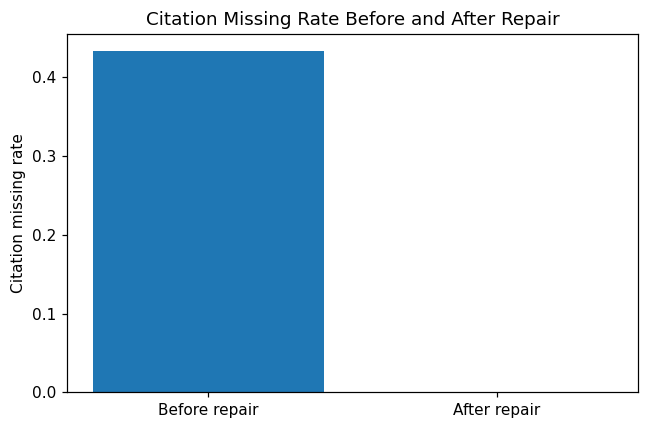

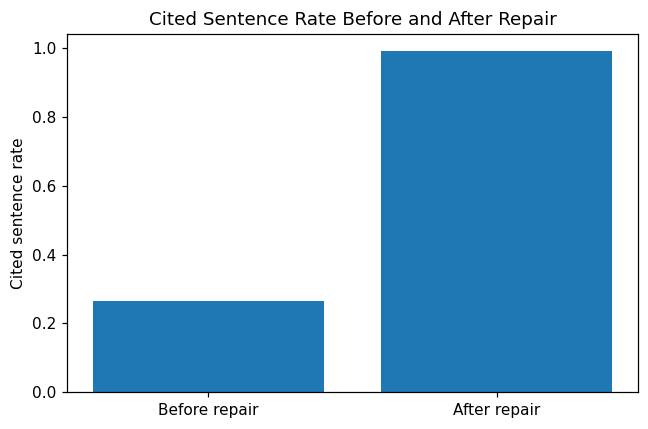

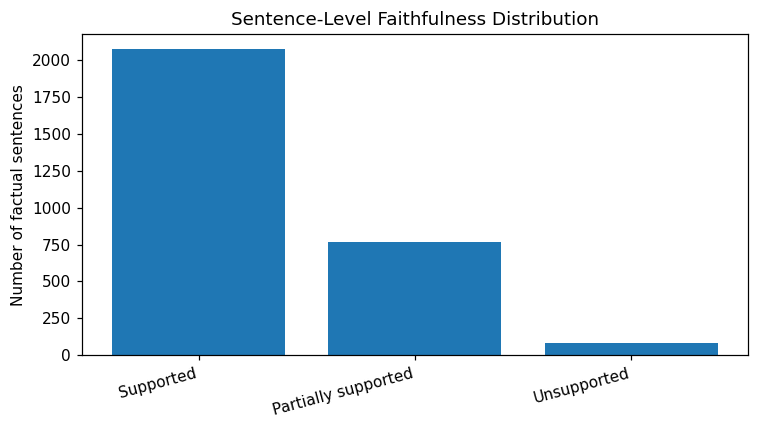

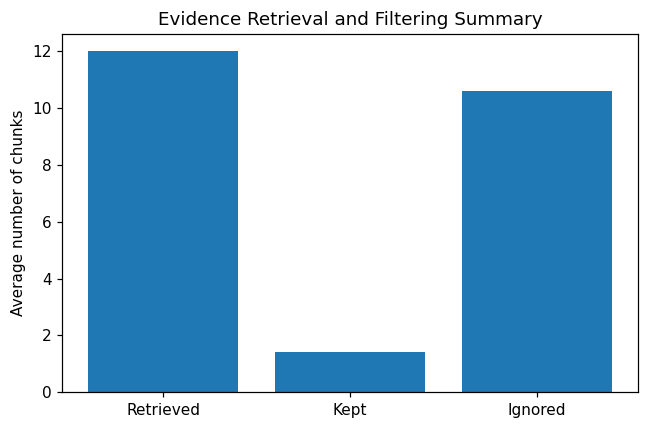

In [20]:
# -----------------------------------------------------------------------------
# Generate and save report plots for the final selected configuration only.
# The plots focus on the final results, citation repair, sentence support, and
# retrieval/evidence retention.
# -----------------------------------------------------------------------------

# --- 1. Final long-answer metrics across answer views ---
# Commented out because final_metrics_df may depend on the PubMedQA-style
# summary evaluation that was skipped.

# metric_view = final_metrics_df.set_index("view")[["rouge1_f1", "rougeL_f1", "bertscore_f1"]]
# metric_view.plot(kind="bar", figsize=(8, 4))
# plt.ylabel("Score")
# plt.title(f"Long-Answer Metrics by Answer View ({FINAL_CONFIG['name']})")
# plt.xticks(rotation=20, ha="right")
# plt.tight_layout()
# plt.savefig(PLOTS_DIR / "plot1_long_answer_metrics_by_view.png")
# plt.show()


# --- 2. BLEU across answer views ---
# Commented out because final_metrics_df may depend on the PubMedQA-style
# summary evaluation that was skipped.

# plt.figure(figsize=(7, 4))
# plt.bar(final_metrics_df["view"], final_metrics_df["bleu"])
# plt.ylabel("BLEU")
# plt.title(f"BLEU by Answer View ({FINAL_CONFIG['name']})")
# plt.xticks(rotation=20, ha="right")
# plt.tight_layout()
# plt.savefig(PLOTS_DIR / "plot2_bleu_by_answer_view.png")
# plt.show()


# --- 3. Citation missing before vs after repair ---
c_before = final_df["citation_format_missing_before"].mean()
c_after = final_df["citation_format_missing_after"].mean()

plt.figure(figsize=(6, 4))
plt.bar(
    ["Before repair", "After repair"],
    [c_before, c_after]
)
plt.ylabel("Citation missing rate")
plt.title("Citation Missing Rate Before and After Repair")
plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "plot3_citation_missing_before_after.png"
)

plt.show()


# --- 4. Cited sentence rate before vs after repair ---
cs_before = final_df["cited_sentence_rate_before"].mean()
cs_after = final_df["cited_sentence_rate_after"].mean()

plt.figure(figsize=(6, 4))
plt.bar(
    ["Before repair", "After repair"],
    [cs_before, cs_after]
)
plt.ylabel("Cited sentence rate")
plt.title("Cited Sentence Rate Before and After Repair")
plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "plot4_cited_sentence_rate_before_after.png"
)

plt.show()


# --- 5. Faithfulness support distribution ---
fc_plot = Counter()

for c in final_df["faith_counts"]:
    fc_plot.update(c)

support_labels = [
    "Supported",
    "Partially supported",
    "Unsupported"
]

support_values = [
    fc_plot["n_supported"],
    fc_plot["n_partially_supported"],
    fc_plot["n_unsupported"],
]

plt.figure(figsize=(7, 4))

plt.bar(
    support_labels,
    support_values
)

plt.ylabel("Number of factual sentences")
plt.title("Sentence-Level Faithfulness Distribution")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "plot5_sentence_faithfulness_distribution.png"
)

plt.show()


# --- 6. Evidence retention summary ---
# Use the actual retrieval-count columns stored in final_df.
# We compute the mean across all PubMedQA questions.

retention_values = [
    final_df["n_retrieved_chunks_total"].mean(),
    final_df["n_retrieved_chunks_kept"].mean(),
    final_df["n_retrieved_chunks_ignored"].mean(),
]

plt.figure(figsize=(6, 4))

plt.bar(
    ["Retrieved", "Kept", "Ignored"],
    retention_values
)

plt.ylabel("Average number of chunks")
plt.title("Evidence Retrieval and Filtering Summary")

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "plot6_evidence_retention_summary.png"
)

plt.show()

## 20. Final results summary + V4 vs V5 comparison

In [21]:
# -----------------------------------------------------------------------------
# Print the final report-ready results summary.
# This is the final configuration and metric block to use in the report.
# -----------------------------------------------------------------------------

print("\n===== FINAL CONFIGURATION SUMMARY =====")

print(
    f"Configuration : {FINAL_CONFIG['name']}  |  Temperature: {best_temp}"
)

print(
    f"  ROUGE-1 (cleaned)   : {summary_clean['rouge1_f1']:.4f}"
)

print(
    f"  ROUGE-L (cleaned)   : {summary_clean['rougeL_f1']:.4f}"
)

print(
    f"  BLEU-4  (cleaned)   : {summary_clean['bleu']:.4f}"
)

print(
    f"  BLEU-1  (cleaned)   : {summary_clean['bleu1']:.4f}"
)

print(
    f"  BERTScore-F1 (clean): {summary_clean['bertscore_f1']:.4f}"
)


# -----------------------------------------------------------------------------
# PubMedQA-style summary metrics are commented because the summary-generation
# cell was skipped/stopped.
# -----------------------------------------------------------------------------

# print(
#     f"  ROUGE-1 (summary)   : {summary_summary['rouge1_f1']:.4f}"
# )

# print(
#     f"  ROUGE-L (summary)   : {summary_summary['rougeL_f1']:.4f}"
# )


print(
    f"  Faithfulness        : {final_df['faithfulness'].mean():.4f}"
)

print(
    f"  Supported sent rate : {fc['n_supported'] / n_fact:.4f}"
)

print(
    f"  Partially supp rate : {fc['n_partially_supported'] / n_fact:.4f}"
)

print(
    f"  Unsupported rate    : {final_df['unsupported_sentence_rate'].mean():.4f}"
)

print(
    f"  Citation consistency: {final_df['citation_consistency'].mean():.4f}"
)

print(
    f"  Citation missing (before -> after): "
    f"{final_df['citation_format_missing_before'].mean():.4f} -> "
    f"{final_df['citation_format_missing_after'].mean():.4f}"
)

print(
    f"  Cited sentences (before -> after) : "
    f"{final_df['cited_sentence_rate_before'].mean():.4f} -> "
    f"{final_df['cited_sentence_rate_after'].mean():.4f}"
)

print(
    f"  Evidence mismatch rate: {final_df['evidence_mismatch'].mean():.4f}"
)

print(
    f"  Same-PMID evidence rate: {final_df['has_gold_evidence'].mean():.4f}"
)

print(
    f"  Config changes vs V4: K=12, threshold=0.58, gentler diversity, query re-ranking,"
)

print(
    f"    adaptive Keep-N, 2-4 sentence target, redesigned prompt for PubMedQA style."
)


===== FINAL CONFIGURATION SUMMARY =====
Configuration : minilm_k12_n3_e058_t02_v5optimized  |  Temperature: 0.2
  ROUGE-1 (cleaned)   : 0.3260
  ROUGE-L (cleaned)   : 0.2103
  BLEU-4  (cleaned)   : 5.4583
  BLEU-1  (cleaned)   : 0.2169
  BERTScore-F1 (clean): 0.8078
  Faithfulness        : 0.8300
  Supported sent rate : 0.3538
  Partially supp rate : 0.1316
  Unsupported rate    : 0.0307
  Citation consistency: 0.9954
  Citation missing (before -> after): 0.4330 -> 0.0010
  Cited sentences (before -> after) : 0.2640 -> 0.9901
  Evidence mismatch rate: 0.0070
  Same-PMID evidence rate: 0.9740
  Config changes vs V4: K=12, threshold=0.58, gentler diversity, query re-ranking,
    adaptive Keep-N, 2-4 sentence target, redesigned prompt for PubMedQA style.


In [22]:
# ============================================================
# V5: Compute comparison metrics + print metric implementations + V4 vs V5 table
# ============================================================

import numpy as np
import pandas as pd

# ---------- Metric Implementation Documentation ----------
print("=" * 60)
print("METRIC IMPLEMENTATION DETAILS")
print("=" * 60)
print(f"BERTScore model        : {BERTSCORE_MODEL} (distilbert-base-uncased)")
print(f"ROUGE implementation   : rouge_score.RougeScorer (rouge1, rougeL, use_stemmer=True)")
print(f"BLEU implementation    : nltk.translate.bleu_score (corpus_bleu, sentence_bleu, SmoothingFunction.method1)")
print(f"BLEU-1 weights         : (1.0, 0, 0, 0)")
print(f"BLEU-4 weights         : (0.25, 0.25, 0.25, 0.25)")
print(f"METEOR implementation  : nltk.translate.meteor_score.meteor_score (WordNet-based)")
print(f"Faithfulness model     : {NLI_MODEL_NAME} (microsoft/deberta-large-mnli)")
print(f"Faithfulness method    : Probabilistic NLI entailment ({ENTAIL_WEIGHT}) + lexical overlap ({OVERLAP_WEIGHT})")
print(f"Answer Relevancy model : {FINAL_CONFIG['embedding_model']} (cosine similarity)")
print(f"All metrics computed on: cleaned_answer_for_metrics vs gold_long_answer")
print(f"Random seed            : {RANDOM_SEED}")
print(f"Evaluation samples     : {N_SAMPLE_QUESTIONS}")
print("=" * 60)


# ---------- Context Precision and Context Recall ----------
def parse_kept_chunks(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            import ast
            return ast.literal_eval(x)
        except Exception:
            return []
    return []

context_precisions = []
context_recalls = []

for _, row in final_df.iterrows():
    gold_pmid = str(row.get("gold_pmid", "")).strip()
    kept_chunks = parse_kept_chunks(row.get("kept_chunks", []))

    if not kept_chunks or gold_pmid == "":
        context_precisions.append(0.0)
        context_recalls.append(0.0)
        continue

    kept_pmids = [str(ch.get("pmid", "")).strip() for ch in kept_chunks]
    relevant_count = sum(1 for pmid in kept_pmids if pmid == gold_pmid)

    context_precision = relevant_count / len(kept_pmids)
    context_recall = 1.0 if relevant_count > 0 else 0.0

    context_precisions.append(context_precision)
    context_recalls.append(context_recall)

context_precision_pct = np.mean(context_precisions) * 100
context_recall_pct = np.mean(context_recalls) * 100


# ---------- Answer Relevancy ----------
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

rel_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

questions = final_df["question"].fillna("").astype(str).tolist()
answers = final_df["cleaned_answer_for_metrics"].fillna("").astype(str).tolist()

q_emb = rel_model.encode(questions, normalize_embeddings=True, show_progress_bar=True)
a_emb = rel_model.encode(answers, normalize_embeddings=True, show_progress_bar=True)

answer_relevancy_scores = [
    cosine_similarity([q_emb[i]], [a_emb[i]])[0][0]
    for i in range(len(final_df))
]

answer_relevancy_pct = np.mean(answer_relevancy_scores) * 100


# ---------- BERTScore Precision and Recall ----------
from bert_score import score as bertscore_score

preds = final_df["cleaned_answer_for_metrics"].fillna("").astype(str).tolist()
refs = final_df["gold_long_answer"].fillna("").astype(str).tolist()

P, R, F1 = bertscore_score(
    preds, refs, lang="en", model_type=BERTSCORE_MODEL,
    verbose=True, device="cpu"
)

bertscore_precision_pct = P.mean().item() * 100
bertscore_recall_pct = R.mean().item() * 100
bertscore_f1_pct = F1.mean().item() * 100


# ---------- METEOR ----------
import nltk
from nltk.translate.meteor_score import meteor_score

nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

meteor_scores = []
for pred, ref in zip(preds, refs):
    pred_tokens = pred.split()
    ref_tokens = ref.split()
    if len(pred_tokens) > 0 and len(ref_tokens) > 0:
        meteor_scores.append(meteor_score([ref_tokens], pred_tokens))
meteor_value = np.mean(meteor_scores)


# ---------- Print V5 Results ----------
print("\n" + "=" * 60)
print("V5 RESULTS")
print("=" * 60)
print(f"Answer Relevancy (%)     : {answer_relevancy_pct:.2f}")
print(f"Context Precision (%)    : {context_precision_pct:.2f}")
print(f"Context Recall (%)       : {context_recall_pct:.2f}")
print(f"BERTScore Precision (%)  : {bertscore_precision_pct:.2f}")
print(f"BERTScore Recall (%)     : {bertscore_recall_pct:.2f}")
print(f"BERTScore F1 (%)         : {bertscore_f1_pct:.2f}")
print(f"METEOR                   : {meteor_value:.4f}")
print(f"Faithfulness             : {final_df['faithfulness'].mean():.4f}")
print(f"Citation consistency     : {final_df['citation_consistency'].mean():.4f}")


# ---------- V4 vs V5 Comparison Table ----------
print("\n" + "=" * 60)
print("V4 vs V5 COMPARISON")
print("=" * 60)

v4_results = {
    "Faithfulness": 0.8625, "Answer Relevancy": 78.89,
    "Context Precision": 90.50, "Context Recall": 96.00,
    "BERT-R": 82.85, "BERT-F1": 80.09,
    "BLEU-1": 0.1925, "ROUGE-1": 0.2960, "METEOR": 0.2459,
}
v5_results = {
    "Faithfulness": final_df['faithfulness'].mean(),
    "Answer Relevancy": answer_relevancy_pct,
    "Context Precision": context_precision_pct,
    "Context Recall": context_recall_pct,
    "BERT-R": bertscore_recall_pct,
    "BERT-F1": bertscore_f1_pct,
    "BLEU-1": summary_clean['bleu1'] if 'summary_clean' in dir() else np.nan,
    "ROUGE-1": summary_clean['rouge1_f1'] if 'summary_clean' in dir() else np.nan,
    "METEOR": meteor_value,
}
targets = {
    "Faithfulness": 0.894, "Answer Relevancy": 82.7,
    "Context Precision": 93.1, "Context Recall": 95.0,
    "BERT-R": 89.0, "BERT-F1": 88.0,
    "BLEU-1": 0.2415, "ROUGE-1": 0.2918, "METEOR": 0.2264,
}

comparison_rows = []
for m in ["Faithfulness", "Answer Relevancy", "Context Precision", "Context Recall",
          "BERT-R", "BERT-F1", "BLEU-1", "ROUGE-1", "METEOR"]:
    v4 = v4_results.get(m, np.nan)
    v5 = v5_results.get(m, np.nan)
    tgt = targets.get(m, np.nan)
    delta = (v5 - v4) if isinstance(v5, (int, float)) and isinstance(v4, (int, float)) else np.nan
    reached = "YES" if isinstance(v5, (int, float)) and isinstance(tgt, (int, float)) and v5 >= tgt else "no"
    comparison_rows.append({
        "Metric": m, "V4": round(v4, 4), "V5": round(v5, 4),
        "Delta": round(delta, 4), "Target": tgt, "Reached": reached,
    })

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))
print("\n" + "=" * 60)

METRIC IMPLEMENTATION DETAILS
BERTScore model        : distilbert-base-uncased (distilbert-base-uncased)
ROUGE implementation   : rouge_score.RougeScorer (rouge1, rougeL, use_stemmer=True)
BLEU implementation    : nltk.translate.bleu_score (corpus_bleu, sentence_bleu, SmoothingFunction.method1)
BLEU-1 weights         : (1.0, 0, 0, 0)
BLEU-4 weights         : (0.25, 0.25, 0.25, 0.25)
METEOR implementation  : nltk.translate.meteor_score.meteor_score (WordNet-based)
Faithfulness model     : microsoft/deberta-large-mnli (microsoft/deberta-large-mnli)
Faithfulness method    : Probabilistic NLI entailment (0.6) + lexical overlap (0.4)
Answer Relevancy model : sentence-transformers/all-MiniLM-L6-v2 (cosine similarity)
All metrics computed on: cleaned_answer_for_metrics vs gold_long_answer
Random seed            : 42
Evaluation samples     : 1000


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/32 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 140.42 seconds, 7.12 sentences/sec

V5 RESULTS
Answer Relevancy (%)     : 79.23
Context Precision (%)    : 90.80
Context Recall (%)       : 97.40
BERTScore Precision (%)  : 78.68
BERTScore Recall (%)     : 83.15
BERTScore F1 (%)         : 80.78
METEOR                   : 0.2557
Faithfulness             : 0.8300
Citation consistency     : 0.9954

V4 vs V5 COMPARISON
           Metric      V4        V5   Delta  Target Reached
     Faithfulness  0.8625  0.830000 -0.0325  0.8940      no
 Answer Relevancy 78.8900 79.231003     NaN 82.7000      no
Context Precision 90.5000 90.800000  0.3000 93.1000      no
   Context Recall 96.0000 97.400000  1.4000 95.0000     YES
           BERT-R 82.8500 83.149500  0.2995 89.0000      no
          BERT-F1 80.0900 80.782900  0.6929 88.0000      no
           BLEU-1  0.1925  0.216900  0.0244  0.2415      no
          ROUGE-1  0.2960  0.326000  0.0300  0.2918     YES
           METEOR  0.2459  0.255700  0.0098  0.2264     YES

